In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
print("Shape:", data.shape)
data.info()

Shape: (15509, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [4]:
print(data.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [5]:
data.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


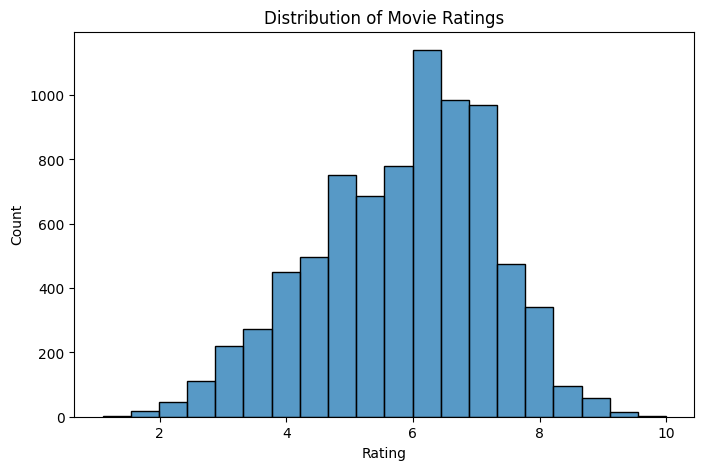

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data['Rating'].dropna(), bins=20)

plt.title('Distribution of Movie Ratings')
plt.show()

In [7]:
data = data[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']]

In [8]:
data = data.dropna()

print(data.shape)

(7558, 6)


In [9]:
le_genre = LabelEncoder()
le_director = LabelEncoder()
le_actor1 = LabelEncoder()
le_actor2 = LabelEncoder()
le_actor3 = LabelEncoder()

data['Genre'] = le_genre.fit_transform(data['Genre'])
data['Director'] = le_director.fit_transform(data['Director'])
data['Actor 1'] = le_actor1.fit_transform(data['Actor 1'])
data['Actor 2'] = le_actor2.fit_transform(data['Actor 2'])
data['Actor 3'] = le_actor3.fit_transform(data['Actor 3'])

In [10]:
X = data.drop('Rating', axis=1)
y = data['Rating']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.028660548941799
Root Mean Squared Error: 1.3099480967366592
R² Score: 0.07387230727003868


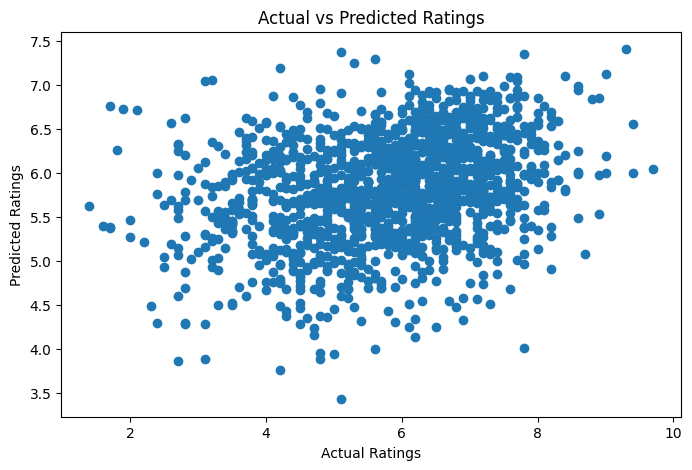

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")

plt.show()

In [16]:
new_movie = pd.DataFrame({
    'Genre':[100],
    'Director':[50],
    'Actor 1':[200],
    'Actor 2':[150],
    'Actor 3':[120]
})

predicted_rating = model.predict(new_movie)

print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 5.891


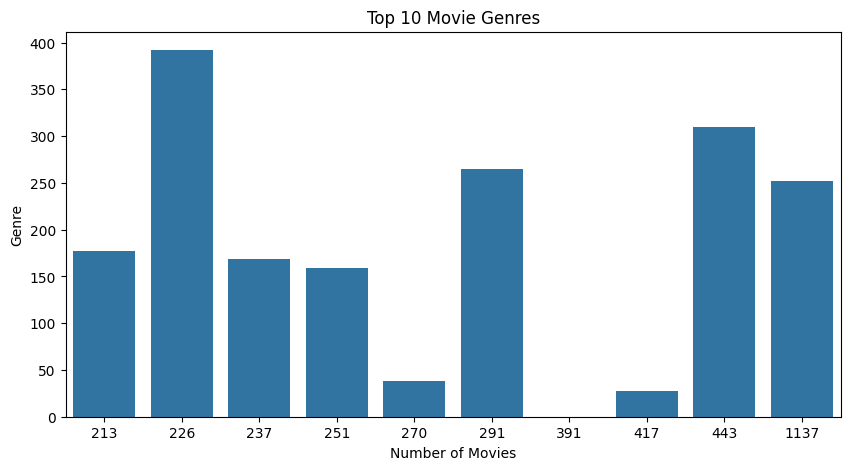

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

top_genres = data['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')

plt.show()